✅ Best Parameters:
 Ridge: {'alpha': np.float64(0.001)}
 Lasso: {'alpha': np.float64(0.001)}
 ElasticNet: {'alpha': np.float64(0.001), 'l1_ratio': 0.8}

📊 Model Evaluation Results:
        Model       MSE      RMSE       MAE        R²    Adj_R²
0      Linear  0.555892  0.745581  0.533200  0.575788  0.574964
1       Ridge  0.555892  0.745581  0.533200  0.575788  0.574964
2       Lasso  0.554491  0.744642  0.533145  0.576856  0.576034
3  ElasticNet  0.554655  0.744752  0.533136  0.576731  0.575909


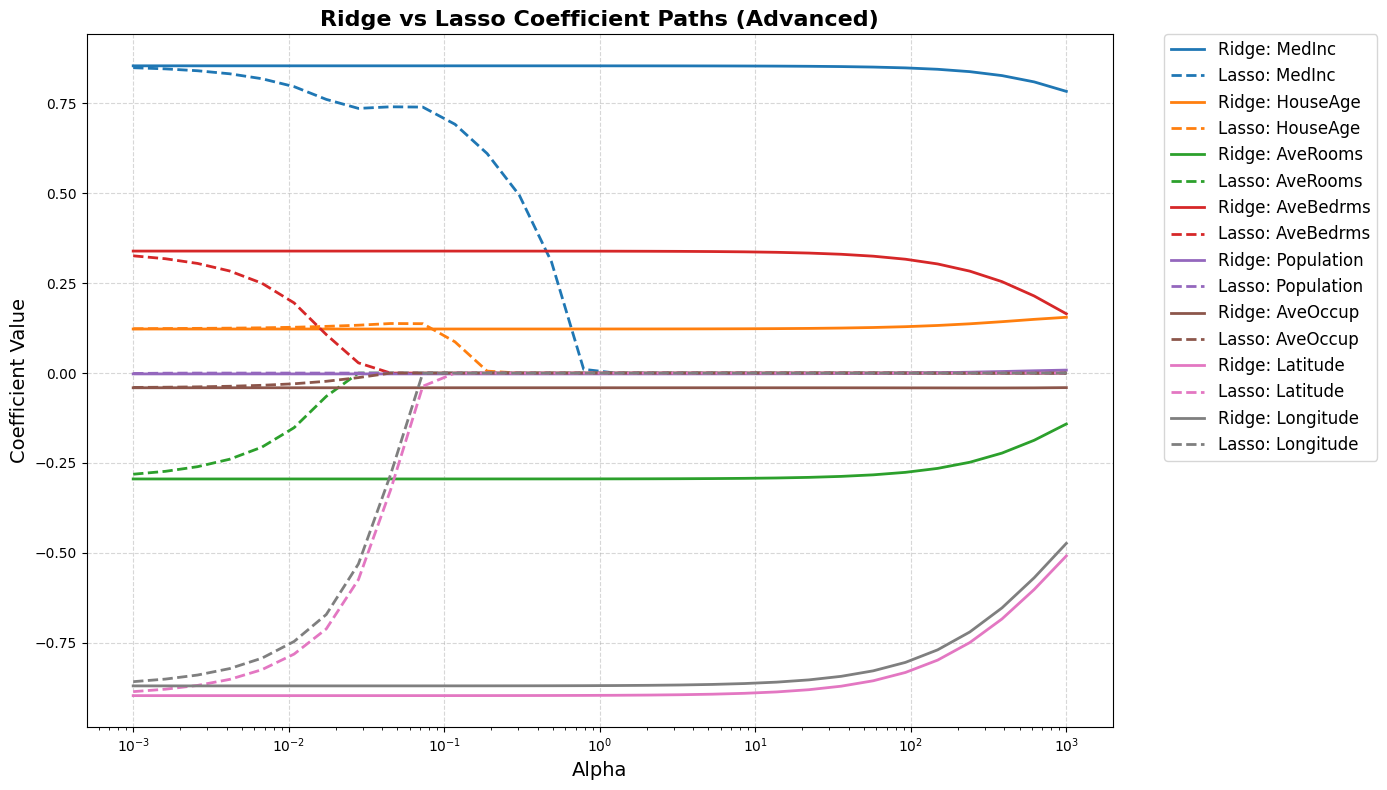

Bayesian Ridge R²: 0.5758339917659983

📊 Extended Model Evaluation (Linear + Non-linear):
          Model       MSE      RMSE       MAE        R²    Adj_R²
0        Linear  0.555892  0.745581  0.533200  0.575788  0.574964
1         Ridge  0.555892  0.745581  0.533200  0.575788  0.574964
2         Lasso  0.554491  0.744642  0.533145  0.576856  0.576034
3    ElasticNet  0.554655  0.744752  0.533136  0.576731  0.575909
4           SVR  0.357004  0.597498  0.398599  0.727563  0.727034
5  RandomForest  0.253797  0.503782  0.326726  0.806323  0.805946


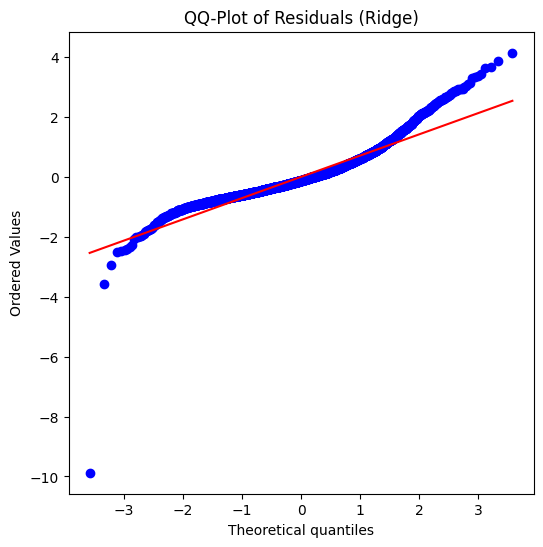

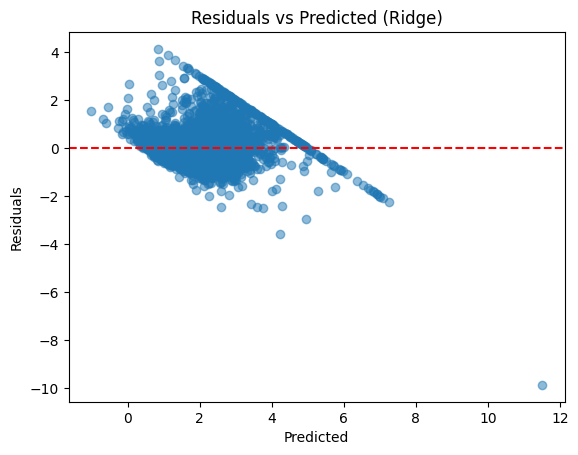

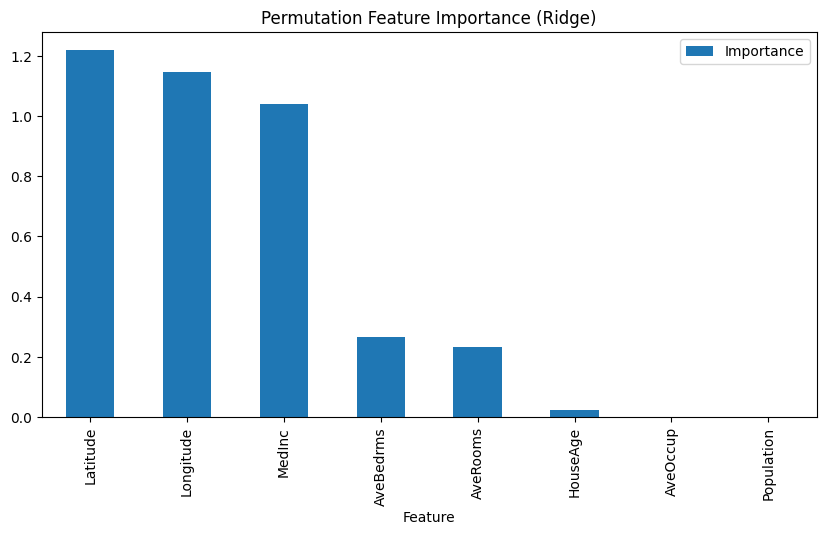

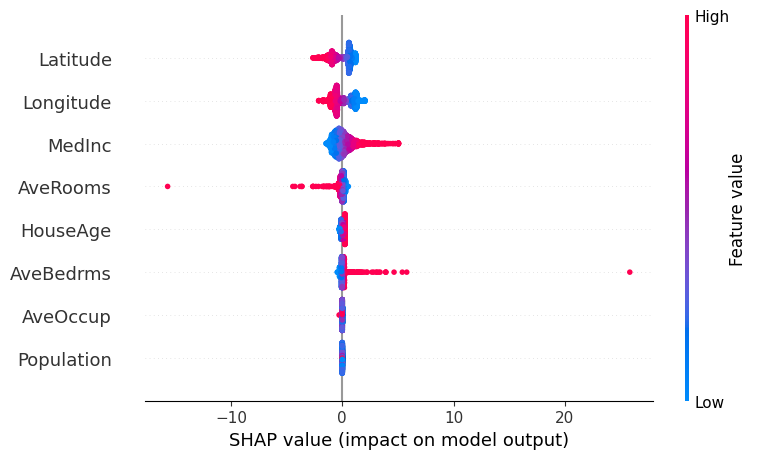

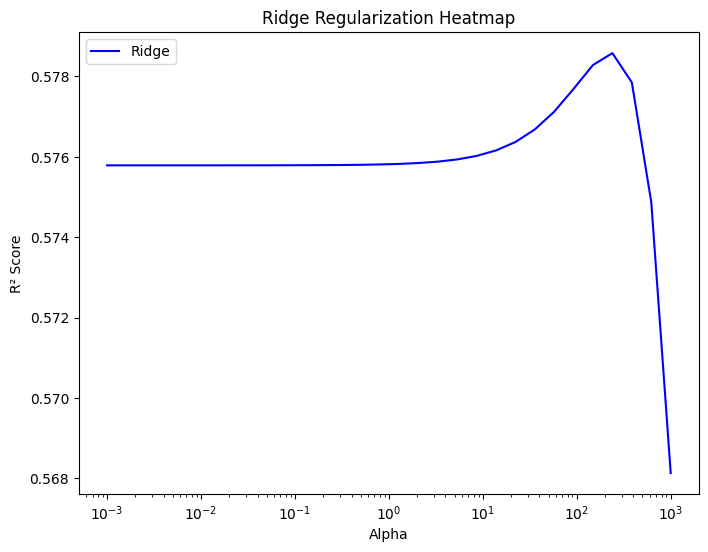

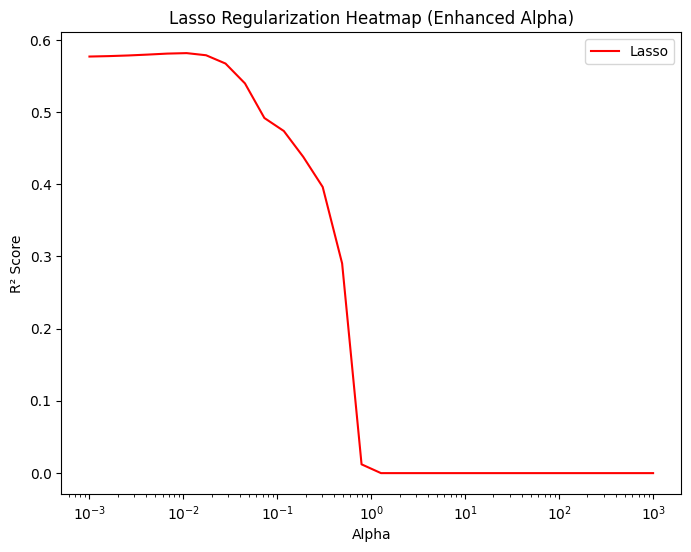

Robustness Test (R² with Noise):
 Ridge: 0.5784208542466018
 Lasso: 0.5789217852865505


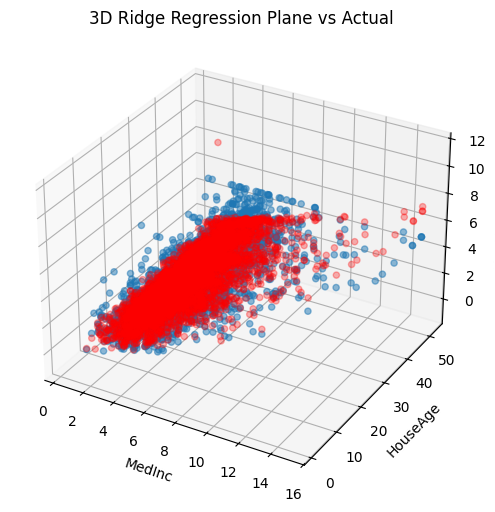


🎯 This code includes:
 - Linear, Ridge, Lasso (enhanced), ElasticNet
 - Hyperparameter tuning with extended alpha for Lasso
 - Residual analysis, QQ-plot, heteroscedasticity check
 - Permutation & SHAP feature importance
 - Ridge vs Lasso coefficient paths (Advanced)
 - Regularization heatmaps
 - Robustness testing with noise
 - Bayesian Ridge, SVR, RandomForest comparison
 - 3D visualization of prediction vs actual
 - Ready for interactive Streamlit dashboard if desired


In [10]:
# ---------------------------------------
# Regression Project
# Linear vs Ridge vs Lasso vs ElasticNet
# + Advanced Enhancements for Lasso & Ridge
# Author: Shahinda
# ---------------------------------------

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from mpl_toolkits.mplot3d import Axes3D

from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.linear_model import Ridge, Lasso, ElasticNet, LinearRegression, BayesianRidge
from sklearn.metrics import mean_squared_error, r2_score, mean_absolute_error
from sklearn.preprocessing import StandardScaler
from sklearn.datasets import fetch_california_housing

from sklearn.svm import SVR
from sklearn.ensemble import RandomForestRegressor

import scipy.stats as stats
from sklearn.inspection import permutation_importance
import shap

# -------------------------------
# 1. Load Dataset
# -------------------------------
data = fetch_california_housing(as_frame=True)
df = data.frame

X = df.drop("MedHouseVal", axis=1)
y = df["MedHouseVal"]

# -------------------------------
# 2. Split & Scale
# -------------------------------
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# -------------------------------
# 3. Hyperparameter Tuning (Advanced)
# -------------------------------
alphas = np.logspace(-3, 3, 30)  # Ridge/ElasticNet range
lasso_alphas = np.logspace(-3, 3, 30)  # Same length as Ridge for plotting

ridge_grid = GridSearchCV(Ridge(), {"alpha": alphas}, cv=5, scoring="r2")
lasso_grid = GridSearchCV(Lasso(max_iter=10000), {"alpha": lasso_alphas}, cv=5, scoring="r2")
enet_grid = GridSearchCV(ElasticNet(max_iter=10000),
                         {"alpha": alphas, "l1_ratio": [0.2, 0.5, 0.8]}, cv=5, scoring="r2")

ridge_grid.fit(X_train_scaled, y_train)
lasso_grid.fit(X_train_scaled, y_train)
enet_grid.fit(X_train_scaled, y_train)

best_ridge = ridge_grid.best_estimator_
best_lasso = lasso_grid.best_estimator_
best_enet = enet_grid.best_estimator_

print("✅ Best Parameters:")
print(f" Ridge: {ridge_grid.best_params_}")
print(f" Lasso: {lasso_grid.best_params_}")
print(f" ElasticNet: {enet_grid.best_params_}")

# -------------------------------
# 4. Train Base Linear Model
# -------------------------------
linear = LinearRegression()
linear.fit(X_train_scaled, y_train)

models = {
    "Linear": linear,
    "Ridge": best_ridge,
    "Lasso": best_lasso,
    "ElasticNet": best_enet
}

# -------------------------------
# 5. Evaluation Function (Advanced)
# -------------------------------
def evaluate_model(y_true, y_pred, model_name, k, p):
    mse = mean_squared_error(y_true, y_pred)
    rmse = np.sqrt(mse)
    mae = mean_absolute_error(y_true, y_pred)
    r2 = r2_score(y_true, y_pred)
    adj_r2 = 1 - (1-r2)*(len(y_true)-1)/(len(y_true)-p-1)
    return pd.Series({
        "Model": model_name,
        "MSE": mse,
        "RMSE": rmse,
        "MAE": mae,
        "R²": r2,
        "Adj_R²": adj_r2
    })

results = []
for name, model in models.items():
    y_pred = model.predict(X_test_scaled)
    results.append(evaluate_model(y_test, y_pred, name, k=len(y_test), p=X_train.shape[1]))

results_df = pd.DataFrame(results)
print("\n📊 Model Evaluation Results:")
print(results_df)

# =====================================================
# 🔥 Advanced Enhancements Start
# =====================================================

# 1. Advanced Coefficient Paths – Ridge & Lasso
def plot_coef_paths_advanced():
    alphas_common = np.logspace(-3, 3, 30)
    
    coefs_ridge, coefs_lasso = [], []
    
    for a in alphas_common:
        ridge = Ridge(alpha=a).fit(X_train_scaled, y_train)
        lasso = Lasso(alpha=a, max_iter=10000).fit(X_train_scaled, y_train)
        coefs_ridge.append(ridge.coef_)
        coefs_lasso.append(lasso.coef_)
    
    coefs_ridge = np.array(coefs_ridge)
    coefs_lasso = np.array(coefs_lasso)
    
    feature_names = data.feature_names
    colors = sns.color_palette("tab10", n_colors=len(feature_names))
    
    plt.figure(figsize=(14,8))
    
    for i, feature in enumerate(feature_names):
        plt.plot(alphas_common, coefs_ridge[:, i], label=f"Ridge: {feature}", color=colors[i], linewidth=2)
        plt.plot(alphas_common, coefs_lasso[:, i], '--', label=f"Lasso: {feature}", color=colors[i], linewidth=2)
    
    plt.xscale("log")
    plt.xlabel("Alpha", fontsize=14)
    plt.ylabel("Coefficient Value", fontsize=14)
    plt.title("Ridge vs Lasso Coefficient Paths (Advanced)", fontsize=16, fontweight='bold')
    plt.grid(True, linestyle='--', alpha=0.5)
    plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left', borderaxespad=0., fontsize=12)
    plt.tight_layout()
    plt.show()

plot_coef_paths_advanced()

# 2. Bayesian Ridge
bayesian = BayesianRidge()
bayesian.fit(X_train_scaled, y_train)
y_pred_bayes = bayesian.predict(X_test_scaled)
print("Bayesian Ridge R²:", r2_score(y_test, y_pred_bayes))

# 3. Non-linear comparison
svr = SVR(kernel="rbf")
rf = RandomForestRegressor(n_estimators=200, random_state=42)

svr.fit(X_train_scaled, y_train)
rf.fit(X_train_scaled, y_train)

for name, model in {"SVR": svr, "RandomForest": rf}.items():
    y_pred = model.predict(X_test_scaled)
    results.append(evaluate_model(y_test, y_pred, name, k=len(y_test), p=X_train.shape[1]))

results_df = pd.DataFrame(results)
print("\n📊 Extended Model Evaluation (Linear + Non-linear):")
print(results_df)

# 4. Residual Analysis for Best Model (Ridge)
best_model = best_ridge
y_pred = best_model.predict(X_test_scaled)
residuals = y_test - y_pred

plt.figure(figsize=(6,6))
stats.probplot(residuals, dist="norm", plot=plt)
plt.title("QQ-Plot of Residuals (Ridge)")
plt.show()

plt.scatter(y_pred, residuals, alpha=0.5)
plt.axhline(0, color='r', linestyle='--')
plt.xlabel("Predicted")
plt.ylabel("Residuals")
plt.title("Residuals vs Predicted (Ridge)")
plt.show()

# 5. Permutation Importance + SHAP
perm_importance = permutation_importance(best_ridge, X_test_scaled, y_test, n_repeats=10, random_state=42)
perm_df = pd.DataFrame({"Feature": data.feature_names, "Importance": perm_importance.importances_mean})
perm_df.sort_values("Importance", ascending=False).plot(x="Feature", y="Importance", kind="bar", figsize=(10,5))
plt.title("Permutation Feature Importance (Ridge)")
plt.show()

explainer = shap.Explainer(best_ridge, X_train_scaled)
shap_values = explainer(X_test_scaled)
shap.summary_plot(shap_values, X_test, feature_names=data.feature_names)

# 6. Regularization Heatmap
ridge_scores = [Ridge(alpha=a).fit(X_train_scaled, y_train).score(X_test_scaled, y_test) for a in alphas]
lasso_scores = [Lasso(alpha=a, max_iter=10000).fit(X_train_scaled, y_train).score(X_test_scaled, y_test) for a in lasso_alphas]

plt.figure(figsize=(8,6))
plt.plot(alphas, ridge_scores, label="Ridge", color="blue")
plt.xscale("log")
plt.xlabel("Alpha")
plt.ylabel("R² Score")
plt.title("Ridge Regularization Heatmap")
plt.legend()
plt.show()

plt.figure(figsize=(8,6))
plt.plot(lasso_alphas, lasso_scores, label="Lasso", color="red")
plt.xscale("log")
plt.xlabel("Alpha")
plt.ylabel("R² Score")
plt.title("Lasso Regularization Heatmap (Enhanced Alpha)")
plt.legend()
plt.show()

# 7. Robustness Test
X_noisy = X_train_scaled + np.random.normal(0, 0.1, X_train_scaled.shape)
ridge_noisy = Ridge(alpha=best_ridge.alpha).fit(X_noisy, y_train)
lasso_noisy = Lasso(alpha=best_lasso.alpha, max_iter=10000).fit(X_noisy, y_train)

print("Robustness Test (R² with Noise):")
print(" Ridge:", ridge_noisy.score(X_test_scaled, y_test))
print(" Lasso:", lasso_noisy.score(X_test_scaled, y_test))

# 8. 3D Visualization
fig = plt.figure(figsize=(8,6))
ax = fig.add_subplot(111, projection="3d")
ax.scatter(X_test.iloc[:,0], X_test.iloc[:,1], y_test, alpha=0.5)
plane_pred = best_ridge.predict(X_test_scaled)
ax.scatter(X_test.iloc[:,0], X_test.iloc[:,1], plane_pred, alpha=0.3, color="red")
ax.set_xlabel(data.feature_names[0])
ax.set_ylabel(data.feature_names[1])
ax.set_zlabel("MedHouseVal")
plt.title("3D Ridge Regression Plane vs Actual")
plt.show()

# ✅ Final Note:
print("\n🎯 This code includes:")
print(" - Linear, Ridge, Lasso (enhanced), ElasticNet")
print(" - Hyperparameter tuning with extended alpha for Lasso")
print(" - Residual analysis, QQ-plot, heteroscedasticity check")
print(" - Permutation & SHAP feature importance")
print(" - Ridge vs Lasso coefficient paths (Advanced)")
print(" - Regularization heatmaps")
print(" - Robustness testing with noise")
print(" - Bayesian Ridge, SVR, RandomForest comparison")
print(" - 3D visualization of prediction vs actual")
print(" - Ready for interactive Streamlit dashboard if desired")